# Stroke Prediciton EDA

## Problem definition
For scenario 1 The problem is to predict whether a patient is likely to experience a stroke based on demographic and health-related features such as age, hypertension, heart disease, and lifestyle factors.
This is a supervised binary classification task, where the model learns from labelled data to classify patients into two categories: stroke or no stroke.
The target variable is stroke, which indicates whether a patient has experienced a stroke (1) or not (0).
Stroke is a serious medical condition with potentially life-threatening consequences. Early identification of high-risk individuals can support preventive interventions and better allocation of healthcare resources. Because stroke cases are relatively rare in the dataset, the problem involves class imbalance, making careful model evaluation critical to avoid missing high-risk patients.

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

## Step 1 load and inspect the data

In [3]:
#Load the data 
df=pd.read_csv("brain_stroke.csv")
df.head()
#df.info()
#df.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [4]:
df['stroke'].value_counts()


stroke
0    4733
1     248
Name: count, dtype: int64

In [5]:
df['smoking_status'].value_counts(dropna=False)


smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

### Inspection findings 
Initial inspection of the dataset shows that all features are relevant to the prediction task and were therefore retained for further analysis. No missing values were detected, indicating good overall data quality. Analysis of the target variable revealed a significant class imbalance, with substantially more non-stroke cases than stroke cases. This imbalance will be taken into account during model training and evaluation by prioritising appropriate performance metrics rather than relying solely on accuracy.

In [7]:
X = df.drop('stroke', axis = 1)
y = df['stroke']

In [8]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
categorical_cols = X_train.select_dtypes(include='object').columns
categorical_cols


Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

Some features in the dataset are categorical and stored as text, whereas machine learning models require numerical inputs. These categorical variables were therefore converted into numerical format using one-hot encoding. This approach was applied consistently to all categorical features, including both binary variables with two categories and variables with multiple categories. One-hot encoding allows each category to be represented without imposing any artificial ordering, ensuring that no information is lost during the transformation.

In [10]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

In [11]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)


In [12]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [13]:
log_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [14]:
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm


array([[709, 238],
       [  8,  42]])

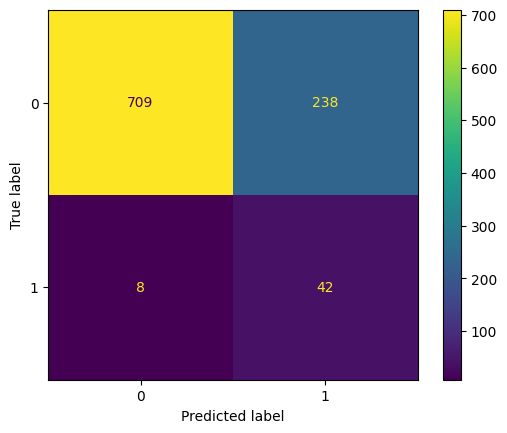

In [15]:
#visual
ConfusionMatrixDisplay(cm).plot()


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       947
           1       0.15      0.84      0.25        50

    accuracy                           0.75       997
   macro avg       0.57      0.79      0.55       997
weighted avg       0.95      0.75      0.82       997



In [17]:
dt = DecisionTreeClassifier(
    class_weight= 'balanced',
    random_state= 42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

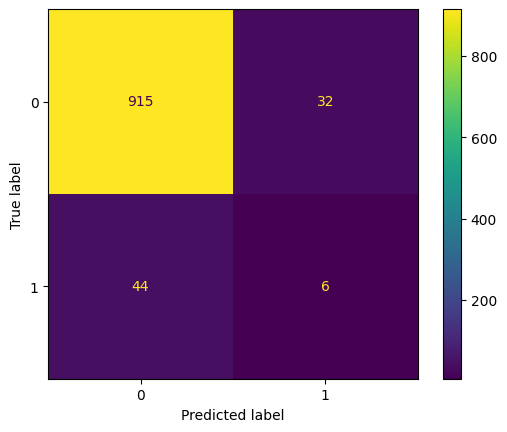

In [18]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot()

In [19]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       947
           1       0.16      0.12      0.14        50

    accuracy                           0.92       997
   macro avg       0.56      0.54      0.55       997
weighted avg       0.91      0.92      0.92       997



A Decision Tree classifier was trained to capture potential non-linear relationships between features and the target variable. Class weighting was applied to address class imbalance. Model performance was evaluated using recall, precision, F1-score, and the confusion matrix to assess improvements over the baseline Logistic Regression model.

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state= 42,
    n_jobs= -1
) 

In [21]:
rf.fit(X_train, y_train)
y_pred_rf= rf.predict(X_test)

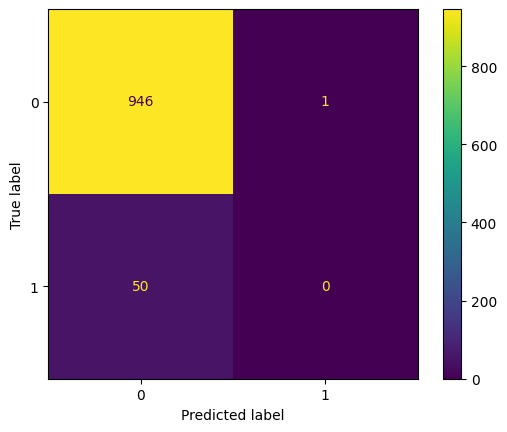

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

In [23]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       947
           1       0.00      0.00      0.00        50

    accuracy                           0.95       997
   macro avg       0.47      0.50      0.49       997
weighted avg       0.90      0.95      0.92       997



## Evaluation

After evaluating multiple classification models, Logistic Regression was selected as the final model for stroke prediction. The decision was based on performance metrics that are most appropriate for an unbalanced medical dataset rather than overall accuracy alone.

# Justification

Before selecting the final model, specific evaluation criteria were prioritised due to the nature of the problem. The most important considerations were minimising false negatives, achieving high recall for the stroke class, and maintaining a balanced F1-score, as the dataset contains significantly more non-stroke cases than stroke cases.

Logistic Regression demonstrated strong recall for the stroke class, correctly identifying the majority of stroke cases and producing a low number of false negatives. This is a critical requirement in a medical context, as failing to identify a patient who has experienced a stroke can have severe consequences. Although the precision of the model was lower, this trade-off was considered acceptable, as false positives are less harmful than false negatives in this scenario.

In comparison, the Decision Tree and Random Forest models achieved higher overall accuracy but showed a stronger bias toward the majority class. While these models reduced false positives, they resulted in a higher number of false negatives and lower recall for the stroke class, making them less suitable for this task despite their higher accuracy.

Class imbalance was addressed using a stratified train-test split and careful metric selection rather than resampling techniques such as SMOTE. This approach preserved the original data distribution and avoided introducing synthetic samples that may not accurately represent real medical cases.

Finally, the selected Logistic Regression model was applied to an unseen dataset using the same preprocessing steps as the training data. As the unseen dataset does not contain ground-truth labels, standard classification metrics could not be calculated. This step was performed to demonstrate model generalisation and deployment readiness.






Testing on Unseen data below

In [25]:
unseen_df = pd.read_csv("brain_stroke_unseen.csv")
unseen_df.info()
unseen_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             499 non-null    object 
 1   age                499 non-null    float64
 2   hypertension       499 non-null    int64  
 3   heart_disease      499 non-null    int64  
 4   ever_married       499 non-null    object 
 5   work_type          499 non-null    object 
 6   Residence_type     499 non-null    object 
 7   avg_glucose_level  499 non-null    float64
 8   bmi                499 non-null    float64
 9   smoking_status     499 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 39.1+ KB


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


In [26]:
unseen_encoded = pd.get_dummies(unseen_df, drop_first=True)

In [28]:
unseen_predictions = log_reg.predict(unseen_encoded)
unseen_predictions = log_reg.predict(unseen_encoded)

In [29]:
predictions_df = pd.DataFrame({
    "Predictions": unseen_predictions
})

In [30]:
predictions_df.to_csv(
    "emmanuel_oloruntola_scenario_1.csv",
    index=False
)